In [ ]:
#Install Required Libraries
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
#Load the Dataset
df = pd.read_csv("processed_land_prices.csv")
df.head()

,Perches,District,Road_Access,Village,Distance_To_Town_km,Total_Price
0,65,Matale,No,West Village,10.7,148491330
1,70,Kandy,Yes,Old Hill,1.1,56522690
2,73,Kandy,No,New Estate,9.3,11194477
3,50,Matara,No,South Hill,6.9,67364400
4,26,Polonnaruwa,Yes,New Colony,1.4,41795624


In [ ]:
#Check Dataset Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Perches              20000 non-null  int64  
 1   District             20000 non-null  object 
 2   Road_Access          20000 non-null  object 
 3   Village              20000 non-null  object 
 4   Distance_To_Town_km  20000 non-null  float64
 5   Total_Price          20000 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 937.6+ KB


In [ ]:
#Encode Categorical Features
label_encoder = LabelEncoder()
df['District'] = label_encoder.fit_transform(df['District'])
df['Road_Access'] = label_encoder.fit_transform(df['Road_Access'])
df['Village'] = label_encoder.fit_transform(df['Village'])

In [ ]:
#Define Features and Target
X = df.drop("Total_Price", axis=1)
y = df["Total_Price"]

In [ ]:
#Split Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Train the Prediction Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Make Predictions
predictions = model.predict(X_test)
print(predictions[:5])

[38547185.08358876 45451976.52999813 63399788.44206215 19104300.42513883
 16771215.87498564]


In [ ]:
#Evaluate Model Performance
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 25065393.78256682
R2 Score: 0.46008366719093996


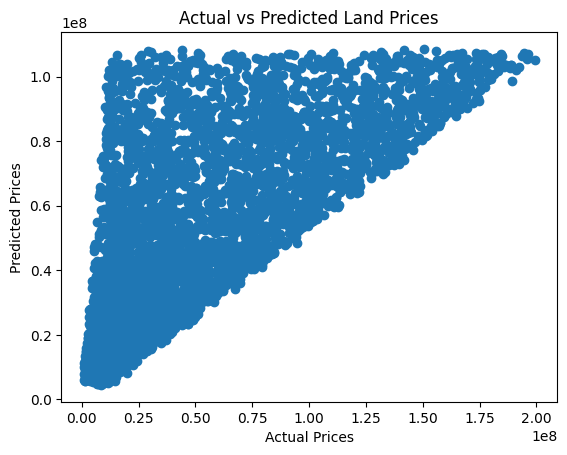

In [ ]:
#Visualize Prediction Results
plt.scatter(y_test, predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Land Prices")
plt.show()

In [ ]:
import pickle
pickle.dump(model, open("land_price_prediction_model.pkl", "wb"))

In [ ]:
from google.colab import files
files.download("land_price_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>